In [4]:
from pyspark.sql import SparkSession

# 停掉残留的旧 session
try:
    spark.stop()
except:
    pass

In [5]:
spark = SparkSession.builder \
    .appName("ChurnPrediction") \
    .master("local[*]") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Spark 版本:", spark.version)
print("连接成功！")

Spark 版本: 3.5.0
连接成功！


In [6]:
# 从本地挂载目录读取数据（Jupyter容器内路径）
df = spark.read.csv(
    "/home/jovyan/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv",
    header=True,
    inferSchema=True
)

# 基本信息
print("总行数:", df.count())
print("总列数:", len(df.columns))
print("\n字段列表:")
df.printSchema()

总行数: 7043
总列数: 21

字段列表:
root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: string (nullable = true)
 |-- Churn: string (nullable = true)



流失分布:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

流失率: 26.5%


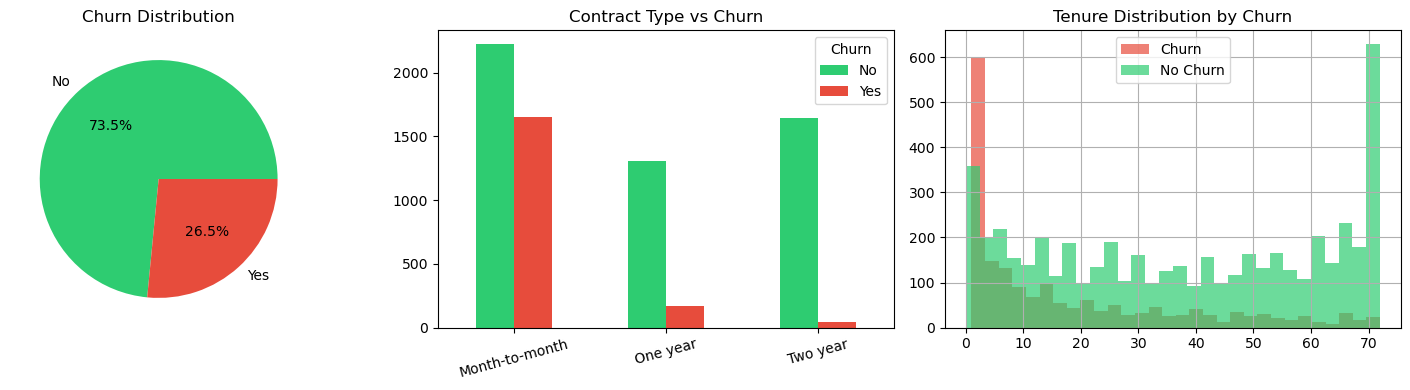

图表已保存！


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']

# 转成 Pandas 方便可视化
pdf = df.toPandas()

# 1. 查看流失比例
churn_counts = pdf['Churn'].value_counts()
print("流失分布:")
print(churn_counts)
print(f"\n流失率: {churn_counts['Yes']/len(pdf)*100:.1f}%")

# 2. 画流失比例饼图
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 饼图
axes[0].pie(churn_counts.values, labels=churn_counts.index, 
            autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'])
axes[0].set_title('Churn Distribution')

# 合同类型 vs 流失
contract_churn = pdf.groupby(['Contract','Churn']).size().unstack()
contract_churn.plot(kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'])
axes[1].set_title('Contract Type vs Churn')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

# 在网时长分布
pdf[pdf['Churn']=='Yes']['tenure'].hist(ax=axes[2], bins=30, 
                                         color='#e74c3c', alpha=0.7, label='Churn')
pdf[pdf['Churn']=='No']['tenure'].hist(ax=axes[2], bins=30, 
                                        color='#2ecc71', alpha=0.7, label='No Churn')
axes[2].set_title('Tenure Distribution by Churn')
axes[2].legend()

plt.tight_layout()
plt.savefig('/home/jovyan/work/eda_overview.png', dpi=100)
plt.show()
print("图表已保存！")

In [8]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

# 1. 修复 TotalCharges（空格转 null，再转 double）
df_clean = df.withColumn(
    "TotalCharges",
    F.when(F.trim(F.col("TotalCharges")) == "", None)
     .otherwise(F.col("TotalCharges").cast(DoubleType()))
)

# 2. 用 MonthlyCharges * tenure 填充 TotalCharges 的空值
df_clean = df_clean.withColumn(
    "TotalCharges",
    F.when(F.col("TotalCharges").isNull(),
           F.col("MonthlyCharges") * F.col("tenure"))
     .otherwise(F.col("TotalCharges"))
)

# 3. 把目标变量 Churn 转成 0/1
df_clean = df_clean.withColumn(
    "label",
    F.when(F.col("Churn") == "Yes", 1).otherwise(0)
)

# 4. 删除不需要的列
df_clean = df_clean.drop("customerID", "Churn")

# 验证
print("清洗后行数:", df_clean.count())
print("TotalCharges 空值数:", df_clean.filter(F.col("TotalCharges").isNull()).count())
print("label 分布:")
df_clean.groupBy("label").count().show()

清洗后行数: 7043
TotalCharges 空值数: 0
label 分布:
+-----+-----+
|label|count|
+-----+-----+
|    1| 1869|
|    0| 5174|
+-----+-----+



In [9]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

# 1. 找出所有类别列和数值列
categorical_cols = [
    "gender", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod"
]

numerical_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

# 2. 对类别列做 StringIndexer + OneHotEncoder
indexers = [
    StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep")
    for c in categorical_cols
]

encoders = [
    OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_vec")
    for c in categorical_cols
]

# 3. 把所有特征合并成一个向量
assembler_inputs = [c+"_vec" for c in categorical_cols] + numerical_cols

assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features",
    handleInvalid="keep"
)

# 4. 构建 Pipeline 并执行
pipeline = Pipeline(stages=indexers + encoders + [assembler])
model = pipeline.fit(df_clean)
df_features = model.transform(df_clean)

# 只保留 features 和 label
df_final = df_features.select("features", "label")

print("特征工程完成！")
print("总样本数:", df_final.count())
df_final.show(3, truncate=True)

特征工程完成！
总样本数: 7043
+--------------------+-----+
|            features|label|
+--------------------+-----+
|(45,[1,3,4,7,10,1...|    0|
|(45,[0,2,4,6,8,12...|    0|
|(45,[0,2,4,6,8,12...|    1|
+--------------------+-----+
only showing top 3 rows



In [10]:
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# 1. 划分训练集和测试集（8:2，固定随机种子保证可复现）
train_df, test_df = df_final.randomSplit([0.8, 0.2], seed=42)
print(f"训练集: {train_df.count()} 条")
print(f"测试集: {test_df.count()} 条")

# 2. 定义评估器
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label", metricName="areaUnderROC"
)
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", metricName="f1"
)

# 3. 训练三个模型
results = {}

# --- Logistic Regression ---
print("\n训练 Logistic Regression...")
lr = LogisticRegression(featuresCol="features", labelCol="label",
                         maxIter=100, regParam=0.01)
lr_model = lr.fit(train_df)
lr_pred = lr_model.transform(test_df)
results["LogisticRegression"] = {
    "AUC": auc_evaluator.evaluate(lr_pred),
    "F1":  f1_evaluator.evaluate(lr_pred)
}

# --- Random Forest ---
print("训练 Random Forest...")
rf = RandomForestClassifier(featuresCol="features", labelCol="label",
                             numTrees=100, seed=42)
rf_model = rf.fit(train_df)
rf_pred = rf_model.transform(test_df)
results["RandomForest"] = {
    "AUC": auc_evaluator.evaluate(rf_pred),
    "F1":  f1_evaluator.evaluate(rf_pred)
}

# --- GBT (XGBoost 替代) ---
print("训练 GBT...")
gbt = GBTClassifier(featuresCol="features", labelCol="label",
                    maxIter=50, seed=42)
gbt_model = gbt.fit(train_df)
gbt_pred = gbt_model.transform(test_df)
results["GBT"] = {
    "AUC": auc_evaluator.evaluate(gbt_pred),
    "F1":  f1_evaluator.evaluate(gbt_pred)
}

# 4. 打印结果对比
print("\n========== 模型对比 ==========")
print(f"{'模型':<20} {'AUC':>8} {'F1':>8}")
print("-" * 38)
for name, metrics in results.items():
    print(f"{name:<20} {metrics['AUC']:>8.4f} {metrics['F1']:>8.4f}")

训练集: 5698 条
测试集: 1345 条

训练 Logistic Regression...
训练 Random Forest...
训练 GBT...

========== 模型对比 ==========
模型                        AUC       F1
--------------------------------------
LogisticRegression     0.8291   0.7985
RandomForest           0.8300   0.7798
GBT                    0.8274   0.7932


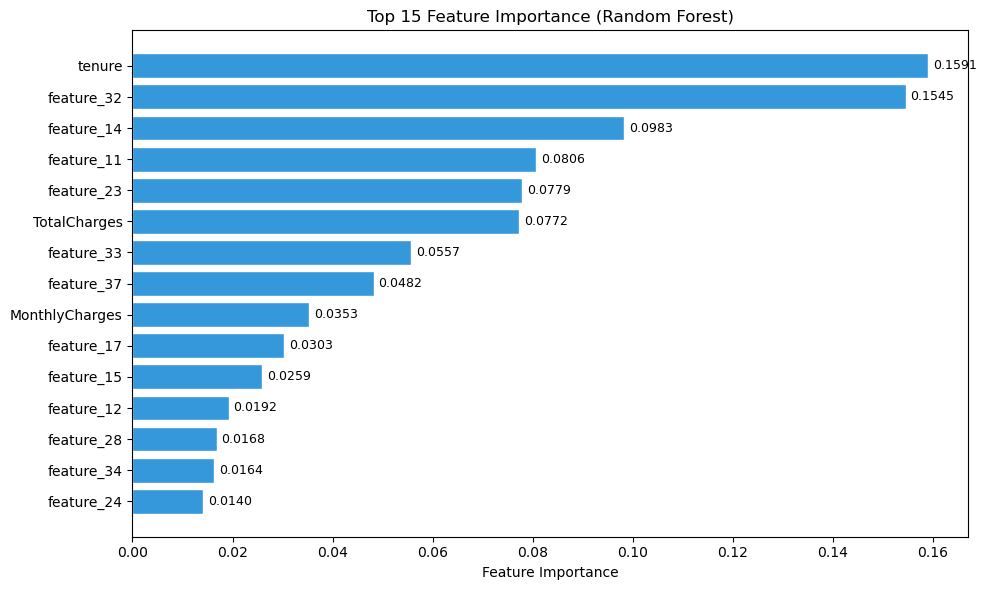

特征总维度: 45
特征重要性图已保存！


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 直接用索引编号作为特征名，再标注重要的几个
importances = rf_model.featureImportances.toArray()

# 用编号命名所有特征
feat_names = [f"feature_{i}" for i in range(len(importances))]

# 构建 DataFrame
feat_df = pd.DataFrame({
    "feature": feat_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(15)

# 手动给重要特征加可读名称（根据位置对应）
# 数值特征在最后4个位置
n = len(importances)
readable = {
    str(n-4): "SeniorCitizen",
    str(n-3): "tenure",
    str(n-2): "MonthlyCharges", 
    str(n-1): "TotalCharges"
}

feat_df["feature"] = feat_df["feature"].apply(
    lambda x: readable.get(x.replace("feature_",""), x)
)

# 画图
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feat_df["feature"][::-1], feat_df["importance"][::-1],
               color="#3498db", edgecolor="white")
ax.set_xlabel("Feature Importance")
ax.set_title("Top 15 Feature Importance (Random Forest)")

for bar, val in zip(bars, feat_df["importance"][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("/home/jovyan/work/feature_importance.png", dpi=100)
plt.show()
print(f"特征总维度: {n}")
print("特征重要性图已保存！")

特征名总数: 45
重要性数组长度: 45


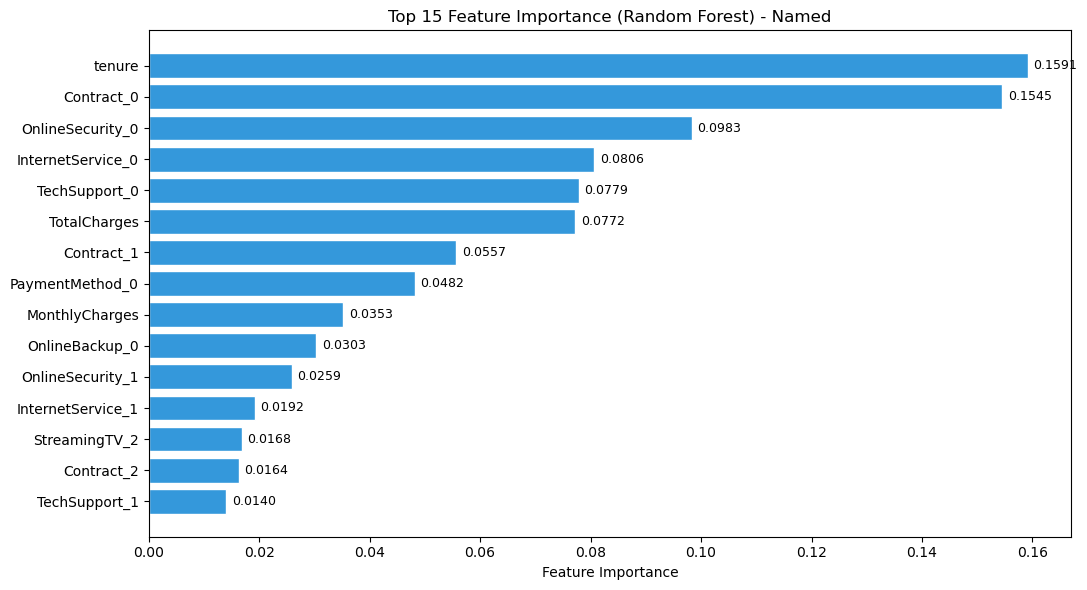

In [13]:
# 还原完整特征名映射
from itertools import chain

# 获取每个类别特征 OHE 之后的实际列数
ohe_sizes = {}
for c in categorical_cols:
    # 从 pipeline model 中取出对应的 OHE 模型
    for stage in model.stages:
        if hasattr(stage, 'categorySizes') and hasattr(stage, 'getInputCol'):
            if stage.getInputCol() == c + "_idx":
                ohe_sizes[c] = stage.categorySizes[0] - 1  # OHE 去掉一列

# 构建完整特征名列表
full_feature_names = []
for c in categorical_cols:
    size = ohe_sizes.get(c, 1)
    for i in range(size):
        full_feature_names.append(f"{c}_{i}")

full_feature_names += numerical_cols  # 最后加数值特征

print(f"特征名总数: {len(full_feature_names)}")
print(f"重要性数组长度: {len(importances)}")

# 构建完整 DataFrame
feat_df2 = pd.DataFrame({
    "feature": full_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(15)

# 画图
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(feat_df2["feature"][::-1], feat_df2["importance"][::-1],
        color="#3498db", edgecolor="white")
ax.set_xlabel("Feature Importance")
ax.set_title("Top 15 Feature Importance (Random Forest) - Named")

for i, (bar, val) in enumerate(zip(ax.patches, feat_df2["importance"][::-1])):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("/home/jovyan/work/feature_importance_named.png", dpi=100)
plt.show()

In [15]:
import subprocess
subprocess.run(["pip", "install", "happybase"], capture_output=True)
print("安装完成！")

安装完成！


In [16]:
import happybase

# 连接 HBase
connection = happybase.Connection('hbase', port=9090)
connection.open()

# 建表
table_name = 'churn_predictions'
if table_name.encode() not in connection.tables():
    connection.create_table(
        table_name,
        {'cf': dict(max_versions=1)}
    )
    print(f"表 {table_name} 创建成功！")
else:
    print(f"表 {table_name} 已存在")

table = connection.table(table_name)
print("HBase 连接成功！")

表 churn_predictions 创建成功！
HBase 连接成功！


In [18]:
import happybase

# 重新建立连接
connection = happybase.Connection('hbase', port=9090)
connection.open()
table = connection.table('churn_predictions')

print("重新连接成功，开始写入...")

# 逐条写入（不用 batch，更稳定）
for i, row in enumerate(predictions):
    row_key = f"user_{i:06d}".encode()
    churn_prob = float(row.probability[1])
    
    if churn_prob >= 0.7:
        risk_level = "HIGH"
    elif churn_prob >= 0.4:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"
    
    table.put(row_key, {
        b'cf:actual_label': str(int(row.label)).encode(),
        b'cf:prediction':   str(int(row.prediction)).encode(),
        b'cf:churn_prob':   f"{churn_prob:.4f}".encode(),
        b'cf:risk_level':   risk_level.encode(),
        b'cf:model':        b'GBT'
    })
    
    # 每100条打印进度
    if (i + 1) % 100 == 0:
        print(f"已写入 {i+1} 条...")

print(f"\n写入完成！共写入 {len(predictions)} 条")

# 验证读取前3条
print("\n验证读取前3条：")
for key, data in table.scan(limit=3):
    print(f"RowKey: {key.decode()}")
    for col, val in data.items():
        print(f"  {col.decode()}: {val.decode()}")
    print()

重新连接成功，开始写入...
已写入 100 条...
已写入 200 条...
已写入 300 条...
已写入 400 条...
已写入 500 条...
已写入 600 条...
已写入 700 条...
已写入 800 条...
已写入 900 条...
已写入 1000 条...
已写入 1100 条...
已写入 1200 条...
已写入 1300 条...

写入完成！共写入 1345 条

验证读取前3条：
RowKey: user_000000
  cf:actual_label: 0
  cf:churn_prob: 0.8616
  cf:model: GBT
  cf:prediction: 1
  cf:risk_level: HIGH

RowKey: user_000001
  cf:actual_label: 0
  cf:churn_prob: 0.5138
  cf:model: GBT
  cf:prediction: 1
  cf:risk_level: MEDIUM

RowKey: user_000002
  cf:actual_label: 1
  cf:churn_prob: 0.8709
  cf:model: GBT
  cf:prediction: 1
  cf:risk_level: HIGH

